In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

from libpysal.weights import KNN
from esda.moran import Moran
from spreg import OLS, ML_Lag

import geopandas as gpd
from shapely.geometry import Point

In [27]:
df = pd.read_csv("/Users/littlestars/Desktop/grain_project/data/raw/final_dataset_region_climate_with_coords.csv")
df.head()

,region,year,production,temp,rain,lat,lon
0,Алтайский край,2006,3518000.0,3.104762,17.850813,52.693224,82.693142
1,Алтайский край,2007,4698310.0,4.821818,17.677519,52.693224,82.693142
2,Алтайский край,2008,3857490.0,3.944815,15.802220,52.693224,82.693142
3,Алтайский край,2009,5627845.0,2.169967,16.615139,52.693224,82.693142
4,Алтайский край,2010,4240800.0,1.055743,13.789200,52.693224,82.693142


In [29]:
df = df.copy()
df = df[df["production"] > 0].copy()
df["log_production"] = np.log(df["production"])
df["temp2"] = df["temp"] ** 2
df["rain2"] = df["rain"] ** 2

In [31]:
yearly = df.groupby("year")[["production", "temp", "rain"]].mean().reset_index()

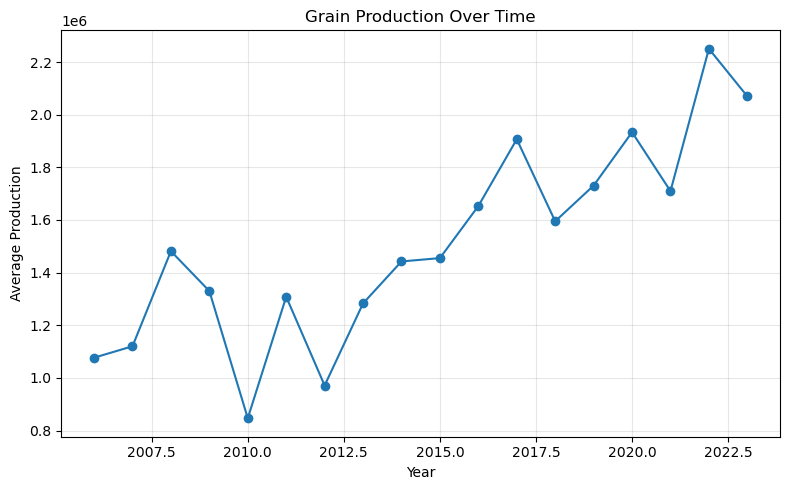

In [35]:
plt.figure(figsize=(8,5))
plt.plot(yearly["year"], yearly["production"], marker="o")
plt.title("Grain Production Over Time")
plt.xlabel("Year")
plt.ylabel("Average Production")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/production_over_time.png", dpi=300)
plt.show()

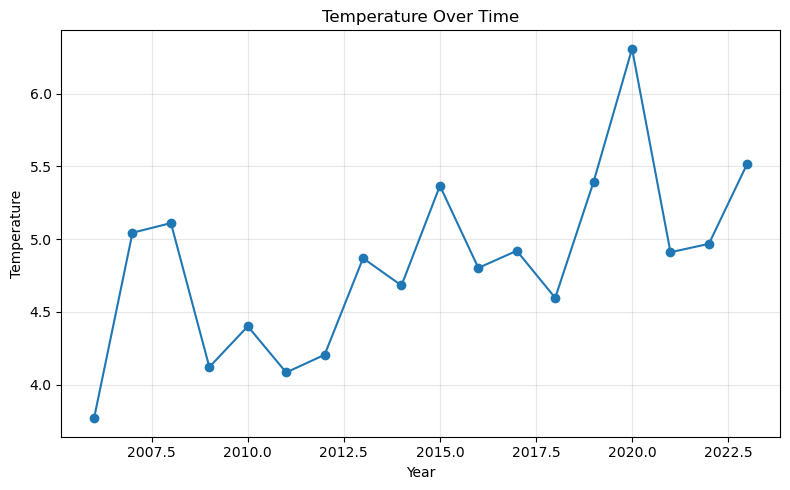

In [37]:
plt.figure(figsize=(8,5))
plt.plot(yearly["year"], yearly["temp"], marker="o")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("Temperature Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/temperature_over_time.png", dpi=300)
plt.show()

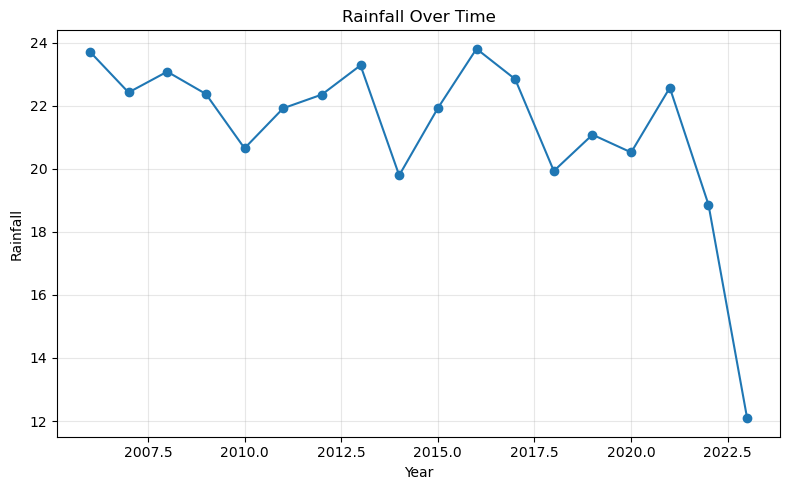

In [39]:
plt.figure(figsize=(8,5))
plt.plot(yearly["year"], yearly["rain"], marker="o")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.title("Rainfall Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/rainfall_over_time.png", dpi=300)
plt.show()

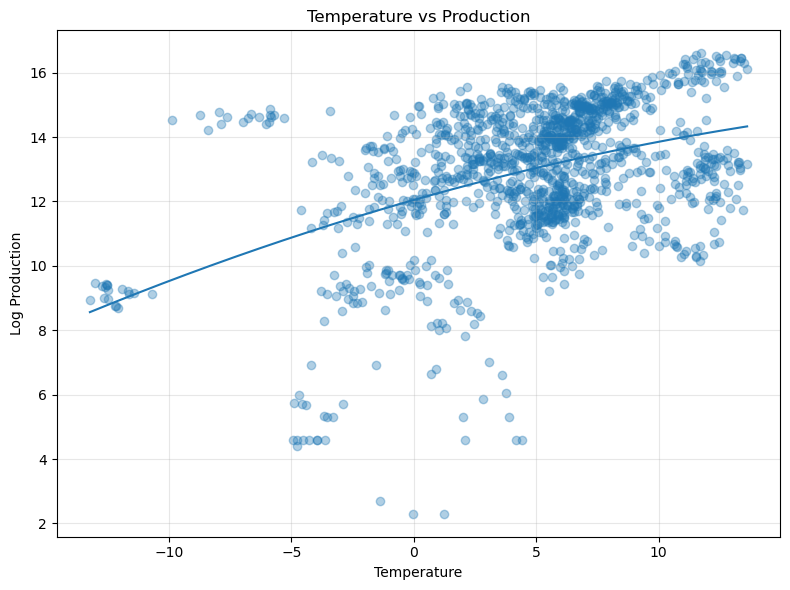

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(df["temp"], df["log_production"], alpha=0.35)
z = np.polyfit(df["temp"], df["log_production"], 2)
p = np.poly1d(z)
x_line = np.linspace(df["temp"].min(), df["temp"].max(), 300)
plt.plot(x_line, p(x_line))
plt.title("Temperature vs Production")
plt.xlabel("Temperature")
plt.ylabel("Log Production")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/temperature_vs_production.png", dpi=300)
plt.show()

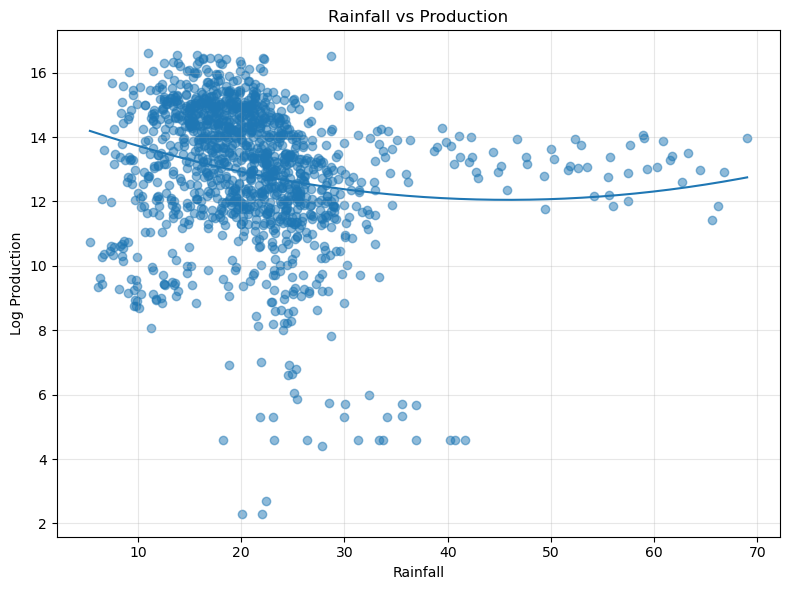

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(df["rain"], df["log_production"], alpha=0.5)
z = np.polyfit(df["rain"], df["log_production"], 2)
p = np.poly1d(z)
x_line = np.linspace(df["rain"].min(), df["rain"].max(), 300)
plt.plot(x_line, p(x_line))
plt.xlabel("Rainfall")
plt.ylabel("Log Production")
plt.title("Rainfall vs Production")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/rainfall_vs_production.png", dpi=300)
plt.show()

In [45]:
panel_df = df.set_index(["region", "year"])

In [47]:
exog_linear = panel_df[["temp", "rain"]]
model_linear = PanelOLS(
    panel_df["log_production"],
    exog_linear,
    entity_effects=True,
    time_effects=True
)
res_linear = model_linear.fit(cov_type="clustered", cluster_entity=True)
print(res_linear)

                          PanelOLS Estimation Summary                           
Dep. Variable:         log_production   R-squared:                        0.0137
Estimator:                   PanelOLS   R-squared (Between):             -0.0306
No. Observations:                1291   R-squared (Within):              -0.0714
Date:                Wed, Mar 25 2026   R-squared (Overall):             -0.0304
Time:                        17:52:31   Log-likelihood                   -419.73
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.3407
Entities:                          74   P-value                           0.0003
Avg Obs:                       17.446   Distribution:                  F(2,1198)
Min Obs:                       6.0000                                           
Max Obs:                       18.000   F-statistic (robust):             5.4993
                            

In [51]:
with open("/Users/littlestars/Desktop/grain_project/results/panel_linear_model.txt", "w", encoding="utf-8") as f:
    f.write(str(res_linear))

In [53]:
exog_nonlinear = panel_df[["temp", "temp2", "rain", "rain2"]]
model_nonlinear = PanelOLS(
    panel_df["log_production"],
    exog_nonlinear,
    entity_effects=True,
    time_effects=True
)
res_nonlinear = model_nonlinear.fit(cov_type="clustered", cluster_entity=True)
print(res_nonlinear)

                          PanelOLS Estimation Summary                           
Dep. Variable:         log_production   R-squared:                        0.0566
Estimator:                   PanelOLS   R-squared (Between):              0.0589
No. Observations:                1291   R-squared (Within):              -0.0598
Date:                Wed, Mar 25 2026   R-squared (Overall):              0.0583
Time:                        17:53:10   Log-likelihood                   -391.02
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.949
Entities:                          74   P-value                           0.0000
Avg Obs:                       17.446   Distribution:                  F(4,1196)
Min Obs:                       6.0000                                           
Max Obs:                       18.000   F-statistic (robust):             9.8323
                            

In [57]:
with open("/Users/littlestars/Desktop/grain_project/results/panel_nonlinear_model.txt", "w", encoding="utf-8") as f:
    f.write(str(res_nonlinear))

In [59]:
region_avg = df.groupby("region").agg(
    avg_production=("production", "mean"),
    avg_log_production=("log_production", "mean"),
    avg_temp=("temp", "mean"),
    avg_rain=("rain", "mean"),
    lat=("lat", "first"),
    lon=("lon", "first")
).reset_index()

region_avg["avg_temp2"] = region_avg["avg_temp"] ** 2
region_avg["avg_rain2"] = region_avg["avg_rain"] ** 2

In [61]:
coords = region_avg[["lon", "lat"]].values
w = KNN.from_array(coords, k=4)
w.transform = "r"

In [63]:
y = region_avg["avg_log_production"].values
moran = Moran(y, w)

print("Moran's I =", moran.I)
print("p-value =", moran.p_sim)

Moran's I = 0.30510383241175315
p-value = 0.002


In [67]:
with open("/Users/littlestars/Desktop/grain_project/results/moran.txt", "w", encoding="utf-8") as f:
    f.write(f"Moran's I = {moran.I}\n")
    f.write(f"p-value = {moran.p_sim}\n")

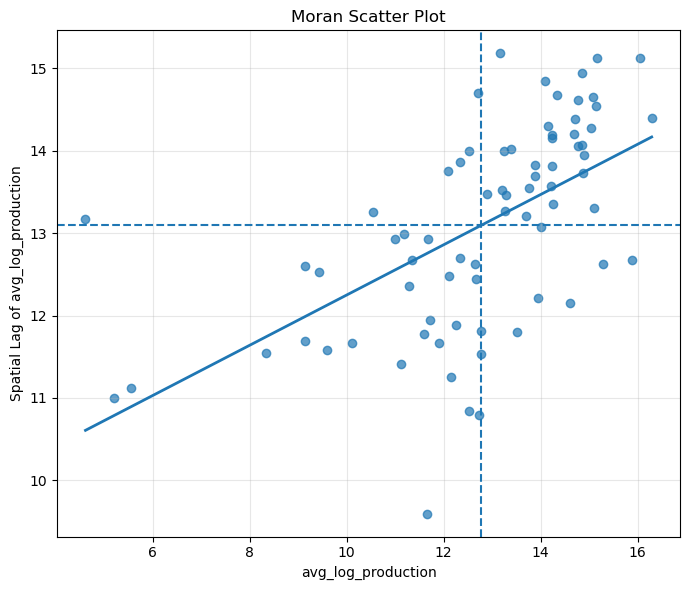

In [71]:
W_dense = w.full()[0]
Wy = W_dense @ y

plt.figure(figsize=(7,6))
plt.scatter(y, Wy, alpha=0.7)

coef = np.polyfit(y, Wy, 1)
line = np.poly1d(coef)
x_line = np.linspace(y.min(), y.max(), 200)
plt.plot(x_line, line(x_line), linewidth=2)

plt.axhline(Wy.mean(), linestyle="--")
plt.axvline(y.mean(), linestyle="--")

plt.xlabel("avg_log_production")
plt.ylabel("Spatial Lag of avg_log_production")
plt.title("Moran Scatter Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/littlestars/Desktop/grain_project/figures/moran_scatter.png", dpi=300)
plt.show()

In [73]:
y_ols = region_avg["avg_log_production"].values.reshape(-1, 1)
X_ols = region_avg[["avg_temp", "avg_temp2", "avg_rain", "avg_rain2"]].values

ols_model = OLS(
    y=y_ols,
    x=X_ols,
    name_y="avg_log_production",
    name_x=["avg_temp", "avg_temp2", "avg_rain", "avg_rain2"]
)
print(ols_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :avg_log_production                Number of Observations:          74
Mean dependent var  :     12.7781                Number of Variables   :           5
S.D. dependent var  :      2.3537                Degrees of Freedom    :          69
R-squared           :      0.2585
Adjusted R-squared  :      0.2155
Sum squared residual:     299.861                F-statistic           :      6.0144
Sigma-square        :       4.346                Prob(F-statistic)     :   0.0003272
S.E. of regression  :       2.085                Log likelihood        :    -156.774
Sigma-square ML     :       4.052                Akaike info criterion :     323.548
S.E of regression ML:      2.0130                Schwarz criterion     :     335.068

------------------------------------------------------

In [75]:
with open("/Users/littlestars/Desktop/grain_project/results/ols_cross_section.txt", "w", encoding="utf-8") as f:
    f.write(str(ols_model.summary))

In [77]:
sar_model = ML_Lag(
    y=y_ols,
    x=X_ols,
    w=w,
    name_y="avg_log_production",
    name_x=["avg_temp", "avg_temp2", "avg_rain", "avg_rain2"]
)
print(sar_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :avg_log_production                Number of Observations:          74
Mean dependent var  :     12.7781                Number of Variables   :           6
S.D. dependent var  :      2.3537                Degrees of Freedom    :          68
Pseudo R-squared    :      0.3687
Spatial Pseudo R-squared:  0.2621
Log likelihood      :   -152.7214
Sigma-square ML     :      3.4698                Akaike info criterion :     317.443
S.E of regression   :      1.8628                Schwarz criterion     :     331.267

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------

In [79]:
with open("/Users/littlestars/Desktop/grain_project/results/sar_model.txt", "w", encoding="utf-8") as f:
    f.write(str(sar_model.summary))